# Segment a scene

Semantic segmentation labels every point in a scene / point cloud.
This notebook will guide you on how to use `torch-pointcloud` library to load pretrained models and perform inference for semantic segmentation tasks. It will cover:

- the **model registry** and the `create_model` factory (the `timm`-style entry point),
- the **inferer API** to run a model over a large scene for inference.

## Setup

In [1]:
# On Colab:
# !pip install "torch-pointcloud[pyg-lib]"

In [2]:
import torch

import torch_pointcloud as tp

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch-pointcloud", tp.__version__, "| device:", device)

torch-pointcloud 0.1.0 | device: cuda


## Download a sample scene

First, let's download a sample scene we will use throughout this notebook.

In [3]:
import urllib.request
from pathlib import Path


def download_sample(filename):
    """Read one object committed with these docs, downloading it when run outside a docs checkout."""
    url = f"https://github.com/arthurdjn/pytorch-pointcloud/raw/main/docs/assets/data/{filename}"
    if not Path(filename).exists():
        urllib.request.urlretrieve(url, filename)

In [4]:
download_sample("sample_scene_labeled.ply")

Let's load the sample scene and visualize it. The room is a ScanNet scene kept as the vertices of its reconstructed mesh, with a color, a normal and a semantic id per vertex. One thing is missing before the checkpoint can read it.

In [5]:
import numpy as np
from plyfile import PlyData

import torch_pointcloud.transforms as T
from torch_pointcloud.datasets.scannet import SCANNET20_LABELS


def load_sample(filename):
    vertex = PlyData.read(filename)["vertex"]
    sample = {
        "pos": torch.from_numpy(np.stack([vertex["x"], vertex["y"], vertex["z"]], axis=1).astype(np.float32)),
        "normal": torch.from_numpy(np.stack([vertex["nx"], vertex["ny"], vertex["nz"]], axis=1).astype(np.float32)),
        "color": torch.from_numpy(np.stack([vertex["red"], vertex["green"], vertex["blue"]], axis=1).astype(np.float32)),
        "segment": torch.from_numpy(np.asarray(vertex["segment"]).astype(np.int64)),
    }
    # Because `segment` holds the raw NYU40 ids, we need to relabel it to the 20-class benchmark specific labels
    # on which the model was trained on.
    return T.Relabel(keys="segment", labels=SCANNET20_LABELS)(sample)


In [25]:
import matplotlib.pyplot as plt


# View defined as: (elevation, azimuth)
ROOM_VIEW = (34, -160) 


def show_cloud(pos, color=None, *, ax=None, title=None, size=1, cmap="viridis", view=ROOM_VIEW):
    """Scatter a point cloud. `pos` is (N, 3); `color` is per-point RGB, a label vector, or None."""
    if ax is None:
        ax = plt.figure(figsize=(4, 4)).add_subplot(projection="3d")

    p = pos.detach().cpu().numpy()
    c = color.detach().cpu().numpy() if torch.is_tensor(color) else color
    kw = {"cmap": cmap} if c is not None and np.ndim(c) == 1 else {}
    ax.scatter(p[:, 0], p[:, 1], p[:, 2], c=c, s=size, depthshade=False, linewidths=0, **kw)
    ax.view_init(elev=view[0], azim=view[1])
    ax.set_box_aspect(p.max(axis=0) - p.min(axis=0), zoom=1.6)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=10)
    return ax


<Axes3D: title={'center': 'Sample scene'}>

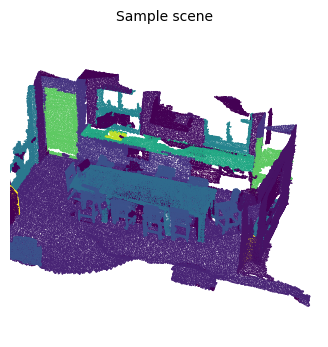

In [26]:
data = load_sample("sample_scene_labeled.ply")
show_cloud(data["pos"], data["segment"], title="Sample scene")

## Find a model in the registry

Models are built by name through a single factory, `create_model`, mirroring `timm.create_model`. Names follow the pattern `<arch>-<variant>.<dataset>`.

You can list what is available for a task with `list_models` (it accepts a glob pattern):

In [27]:
from torch_pointcloud.models import list_models

list_models("*pointcept*", task="segmentation", pretrained=True)
# ['concerto-large-lp.scannet20.pointcept',
#  'ptv3-base.s3dis-area5.pointcept',
#  'ptv3-base.scannet20.pointcept',
#  'ptv3-base.scannet200.pointcept',
#  'spunet-v1m1.scannet20.pointcept',
#  'utonia-lp.scannet20.pointcept']

['concerto-large-lp.scannet20.pointcept',
 'ptv3-base.s3dis-area5.pointcept',
 'ptv3-base.scannet20.pointcept',
 'ptv3-base.scannet200.pointcept',
 'spunet-v1m1.scannet20.pointcept',
 'utonia-lp.scannet20.pointcept']

The `create_model` returns a typed `SegmentationModel` -- a regular `torch.nn.Module`, so `.eval()`, and `.to(device)` work as usual.

In [ ]:
model, info = tp.create_model(
    "spunet-v1m1.scannet20.pointcept",
    task="segmentation",
    pretrained=True,
    return_info=True,
)
model = model.eval().to(device)
# On Colab: !pip install "torch-pointcloud[pyg-lib]"
classes = list(info["weights"]["classes"])
print(len(classes), "classes:", ", ".join(classes))

20 classes: wall, floor, cabinet, bed, chair, sofa, table, door, window, bookshelf, picture, counter, desk, curtain, refrigerator, showercurtain, toilet, sink, bathtub, otherfurniture


## Run the model

A segmentation model is called as `model(x, pos, batch)`: features first, then coordinates, then the batch index. It returns a logits vector per point, shape $(N, C_\text{out})$.

However SpUNet is a voxel backbone, so it never reads the raw points as floats: the model expects a voxelized scene.
This specific model was pretrained on ScanNet20 with scenes voxelized at 2 cm. This specific transform is stored in the associated `info` dict (use `return_info=True` when creating the model to access it).

Note that because raw coordinates `pos` are voxelized into `pos_grid`, the number of points in `pos_grid` is smaller than the ones in `pos` (the voxelized scene contains only one point per voxel).

In [29]:
from torch_pointcloud.utils.data import collate

data_list = [load_sample(filename) for filename in ("sample_scene_labeled.ply",)]
data_list = [info["transform"](data) for data in data_list]
data = collate(data_list, cat_keys="pos_grid")

print(data.keys())
for key in data.keys():
    print(f"{key}: {data[key].shape}")

# dict_keys(['pos', 'normal', 'color', 'segment', 'x', 'target', 'pos_grid', 'inverse', 'batch', 'batch_pos_grid'])
# pos: torch.Size([127410, 3])           # The original coordinates
# normal: torch.Size([127410, 3])        # Raw normals
# color: torch.Size([127410, 3])         # Raw colors
# segment: torch.Size([127410])          # Raw NYU40 ids
# x: torch.Size([114118, 6])             # Voxelized features
# target: torch.Size([114118])           # Voxelized labels
# pos_grid: torch.Size([114118, 3])      # Voxel coordinates
# inverse: torch.Size([127410])          # Inverse mapping from raw points to voxels
# batch: torch.Size([127410])            # Batch index for each point
# batch_pos_grid: torch.Size([114118])   # Batch index for each voxel

dict_keys(['pos', 'normal', 'color', 'segment', 'x', 'target', 'pos_grid', 'inverse', 'batch', 'batch_pos_grid'])
pos: torch.Size([127410, 3])
normal: torch.Size([127410, 3])
color: torch.Size([127410, 3])
segment: torch.Size([127410])
x: torch.Size([114118, 6])
target: torch.Size([114118])
pos_grid: torch.Size([114118, 3])
inverse: torch.Size([127410])
batch: torch.Size([127410])
batch_pos_grid: torch.Size([114118])


In [30]:
model = model.eval().to(device)
with torch.no_grad():
    logits = model(data["x"].to(device), data["pos_grid"].to(device), data["batch_pos_grid"].to(device))

print("logits:", logits.shape)
# logits: torch.Size([114118, 20])

logits: torch.Size([114118, 20])


## Visualize the predictions

Turn logits into probabilities and map predicted labels (voxel-wise) to per-point labels. We will use the `inverse` key to map the logits back to the original points (revert the voxelization that occurred in the transforms).

In [31]:
logits = logits[data["inverse"].to(device)]
preds = logits.argmax(dim=-1).cpu()
print(f"logits.shape: {logits.shape}")
print(f"pos.shape: {data['pos'].shape}")


logits.shape: torch.Size([127410, 20])
pos.shape: torch.Size([127410, 3])


In [32]:
from torch_pointcloud.utils.metrics import confusion_matrix

target = data["segment"]
annotated = target >= 0
matrix = confusion_matrix(preds, target, model.num_classes, ignore_index=-1)
union = matrix.sum(0) + matrix.sum(1) - matrix.diag()
iou = matrix.diag() / union.clamp_min(1)

print(f"annotated points: {int(annotated.sum())} of {len(target)}")
print(f"accuracy: {(preds[annotated] == target[annotated]).float().mean():.3f}")
print(f"mIoU over the {int((union > 0).sum())} classes involved: {iou[union > 0].mean():.3f}")


annotated points: 108834 of 127410
accuracy: 0.906
mIoU over the 14 classes involved: 0.585


To see *where* the model is wrong, color the room by whether each point came back right, and put the per-class IoU next to it. The pale points are the ones the room carries no label for, which both metrics leave out through `ignore_index=-1`.


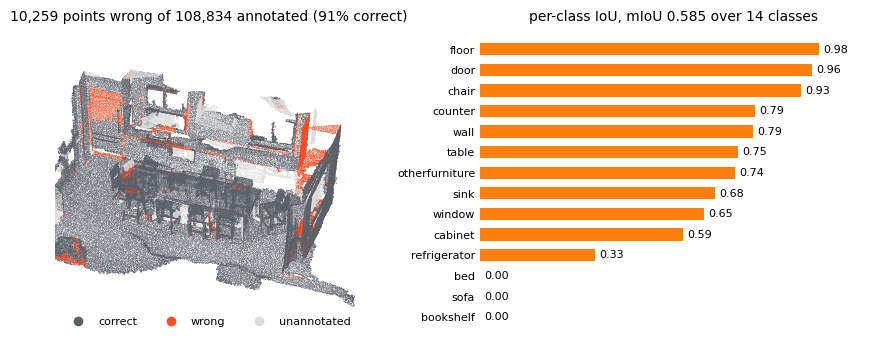

In [14]:
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D

CORRECT, WRONG, UNANNOTATED = "#5c6068", "#ff4c22", "#dcdcdc"


def show_prediction(preds):
    """Color the room by whether each point came back right, beside the per-class IoU of that run."""
    matrix = confusion_matrix(preds, target, model.num_classes, ignore_index=-1)
    union = matrix.sum(0) + matrix.sum(1) - matrix.diag()
    iou = matrix.diag() / union.clamp_min(1)
    present = torch.nonzero(union > 0).flatten()
    ranked = present[iou[present].argsort(descending=True)]
    wrong = annotated & (preds != target)
    accuracy = (preds[annotated] == target[annotated]).float().mean()

    fig = plt.figure(figsize=(11, 4))
    ax = show_cloud(
        data["pos"],
        color=np.array([to_rgb(UNANNOTATED), to_rgb(CORRECT), to_rgb(WRONG)])[annotated.long() + wrong.long()],
        ax=fig.add_subplot(121, projection="3d"),
        title=f"{int(wrong.sum()):,} points wrong of {int(annotated.sum()):,} annotated ({accuracy:.0%} correct)",
        size=0.4,
    )
    ax.legend(
        handles=[
            Line2D([], [], marker="o", linestyle="", color=color, label=name)
            for name, color in (("correct", CORRECT), ("wrong", WRONG), ("unannotated", UNANNOTATED))
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.0),
        ncol=3,
        frameon=False,
        fontsize=8,
    )

    ax = fig.add_subplot(122)
    bars = ax.barh([classes[int(index)] for index in ranked], iou[ranked].tolist(), color="tab:orange", height=0.6)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0.0, 1.12)
    ax.set_xticks([])
    ax.tick_params(length=0, labelsize=8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(f"per-class IoU, mIoU {iou[present].mean():.3f} over {len(present)} classes", fontsize=10)


show_prediction(preds)


![The committed room with its misclassified points picked out in red, beside a bar chart of per-class IoU running from floor at 0.98 down to three classes at zero.](../assets/tutorials/segmentation_room_errors.png)

## Using an inferer

An [inferer](../inferers/overview.md) takes a packed-batch dict and a `predictor` callable, and returns one prediction per input point, shape $(N, C_\text{out})$, aligned to the input order.

### Simple Inferer

This inferer runs the predictor on the whole scene at once, so it is just a wrapper around the `forward` method of the model -- but it adheres to the inferer API.

In [ ]:
from torch_pointcloud.inferers import SimpleInferer, SlidingWindowInferer

scene = collate([load_sample("sample_scene_labeled.ply")])


def spunet_predictor(data):
    # Apply the inference transform to the specific input data
    data = info["transform"]({key: value.clone() for key, value in data.items() if torch.is_tensor(value)})
    pos_grid = data["pos_grid"].to(device)
    batch = torch.zeros(len(pos_grid), dtype=torch.long, device=device)
    logits = model(data["x"].to(device), pos_grid, batch)
    return logits[data["inverse"].to(device)].cpu()


In [ ]:
inferer = SimpleInferer()
preds_whole = inferer(scene, predictor=spunet_predictor)
print("output:", tuple(preds_whole.shape))

### Sliding Window Inferer

When the scene is too large for one pass, `SlidingWindowInferer` tiles it into cubic blocks of a fixed metric size, runs the predictor on each, and blends overlapping predictions. With `mode="gaussian"` points near a block center count more than those at the seam, which softens block boundaries.


In [ ]:
inferer = SlidingWindowInferer(block_size=2.0, overlap=0.25, mode="gaussian")
preds_tiled = inferer(scene, predictor=spunet_predictor)
print("output:", tuple(preds_tiled.shape))

In [ ]:
print("labels that differ from the whole-scene run:", int((preds_tiled.argmax(-1) != preds_whole.argmax(-1)).sum()))

fig = plt.figure(figsize=(9, 4))
show_cloud(data["pos"], color=preds_whole.argmax(-1), ax=fig.add_subplot(121, projection="3d"), title="whole scene at once", size=0.4)
show_cloud(data["pos"], color=preds_tiled.argmax(-1), ax=fig.add_subplot(122, projection="3d"), title="stitched from 2 m blocks", size=0.4);


### Test-time augmentation Inferer 

Test-time augmentation wraps a base inferer and runs several augmented passes of the input and averages them.

In [ ]:
from torch_pointcloud.inferers import TTAInferer
from torch_pointcloud.transforms import RandomRotate

views = [
    RandomRotate(keys=("pos", "normal"), angle_range=(angle, angle), axis=2, p=1.0)
    for angle in (0.0, 90.0, 180.0, 270.0)
]
inferer = TTAInferer(base=SimpleInferer(softmax=True), transforms=views)
voted = inferer(scene, predictor=spunet_predictor).argmax(dim=-1).cpu()

matrix = confusion_matrix(voted, target, model.num_classes, ignore_index=-1)
union = matrix.sum(0) + matrix.sum(1) - matrix.diag()
iou = matrix.diag() / union.clamp_min(1)
print(f"accuracy: {(voted[annotated] == target[annotated]).float().mean():.3f}")
print(f"mIoU over the {int((union > 0).sum())} classes involved: {iou[union > 0].mean():.3f}")


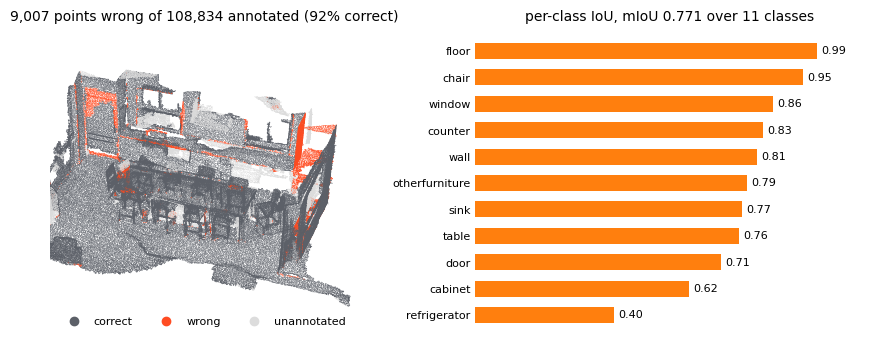

In [20]:
show_prediction(voted)

![TTA](../assets/tutorials/segmentation_tta_errors.png)

## Ensembling

The below cell is just an example of ensembling different models using the `TTAInferer` and `SimpleInferer`.

In [ ]:
def probabilities(name):
    member, member_info = tp.create_model(name, task="segmentation", pretrained=True, return_info=True)
    member = member.eval().to(device)

    def predictor(data):
        window = member_info["transform"]({key: value.clone() for key, value in data.items() if torch.is_tensor(value)})
        pos_grid = window["pos_grid"].to(device)
        batch = torch.zeros(len(pos_grid), dtype=torch.long, device=device)
        logits = member(window["x"].to(device), pos_grid, batch)
        return logits[window["inverse"].to(device)]

    inferer = TTAInferer(
        base=SimpleInferer(softmax=True), 
        transforms=views
    )
    voted = inferer(scene, predictor=predictor)

    member.cpu()
    torch.cuda.empty_cache()
    return voted.cpu()


model_names = ("spunet-v1m1.scannet20.pointcept", "concerto-large-lp.scannet20.pointcept")
merged = torch.stack([probabilities(name) for name in model_names]).mean(dim=0).argmax(dim=-1)

matrix = confusion_matrix(merged, target, model.num_classes, ignore_index=-1)
union = matrix.sum(0) + matrix.sum(1) - matrix.diag()
iou = matrix.diag() / union.clamp_min(1)
print(f"accuracy: {(merged[annotated] == target[annotated]).float().mean():.3f}")
print(f"mIoU over the {int((union > 0).sum())} classes involved: {iou[union > 0].mean():.3f}")


accuracy: 0.950
mIoU over the 12 classes involved: 0.785


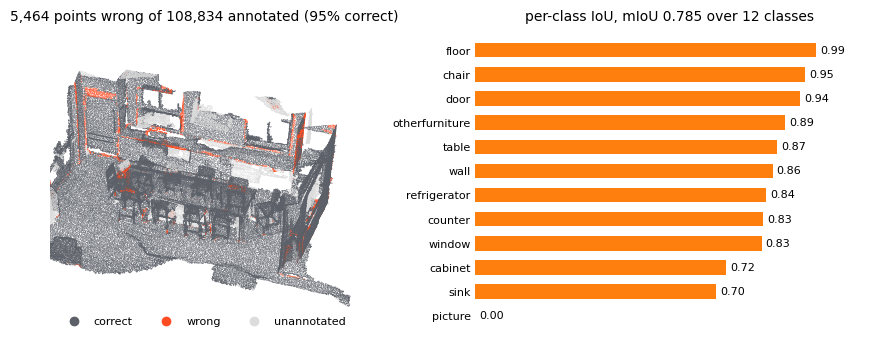

In [22]:
show_prediction(merged)

![The room under a two-checkpoint ensemble, with the fewest red points of the three runs, beside a bar chart of per-class IoU running from floor at 0.99 down to sink at 0.70.](../assets/tutorials/segmentation_ensemble_errors.png)